Saving insurance.csv to insurance (2).csv
✅ Dataset Loaded Successfully!


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Shapes — Train: (936, 8), Val: (268, 8), Test: (134, 8)
🔄 Running Linear with 5-Fold Cross Validation...
🔄 Running Lasso with 5-Fold Cross Validation...
🔄 Running Ridge with 5-Fold Cross Validation...
🔄 Running ElasticNet with 5-Fold Cross Validation...

📊 Cross-Validation Summary:


,Model,R2_mean,R2_std,RMSE_mean,RMSE_std
2,Ridge,0.735238,0.031706,6313.331921,327.141395
0,Linear,0.735100,0.031730,6314.945293,326.949876
1,Lasso,0.734099,0.030633,6328.202501,319.540171
3,ElasticNet,0.734099,0.030633,6328.202501,319.540171


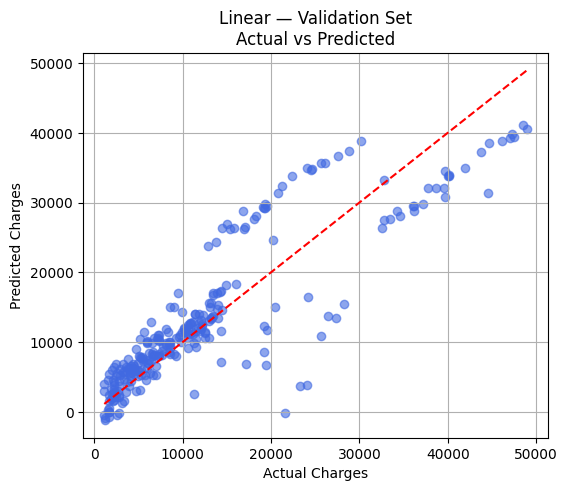

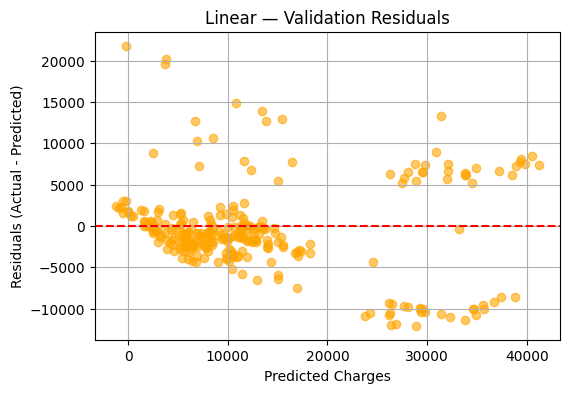

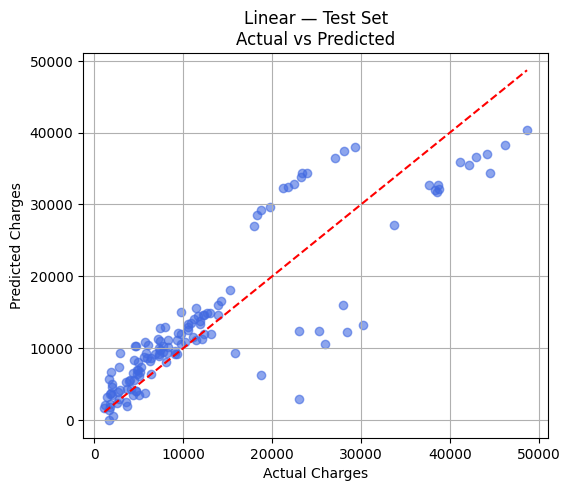

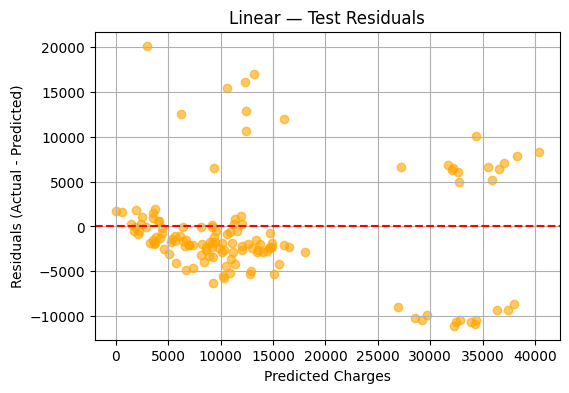

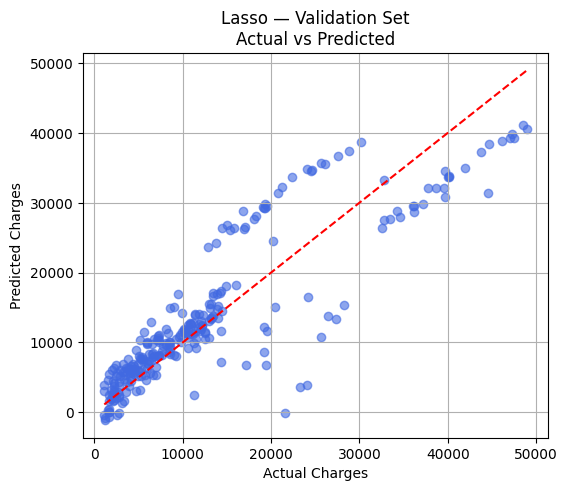

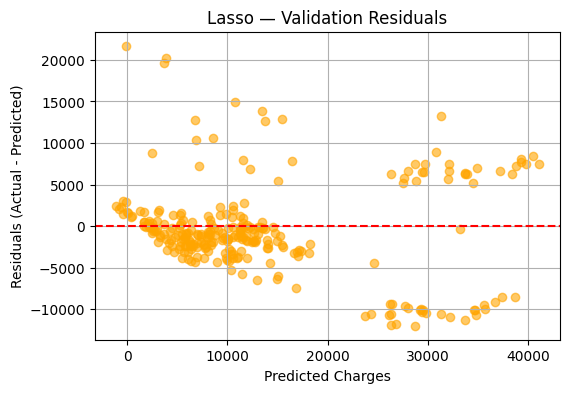

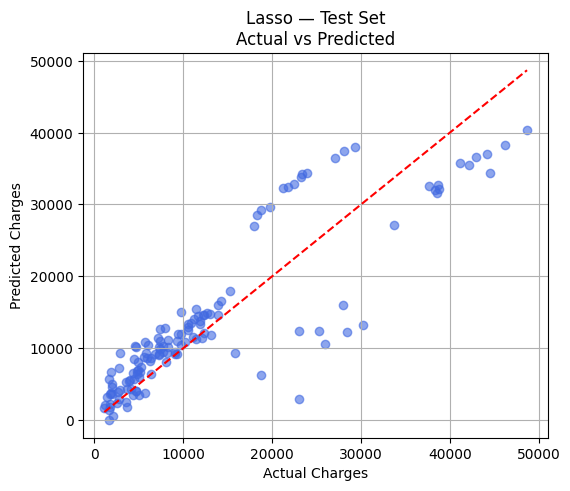

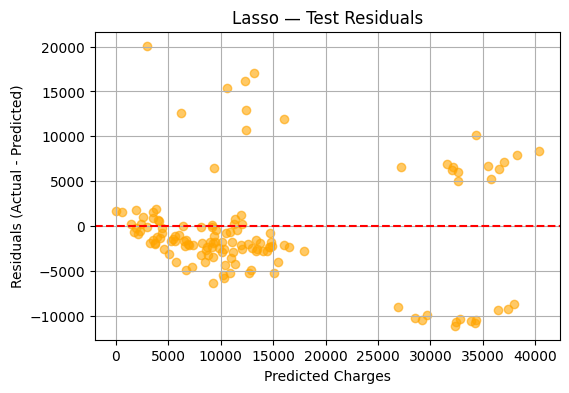

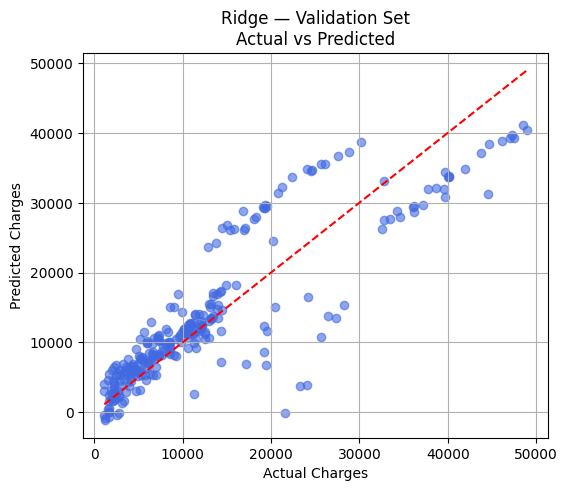

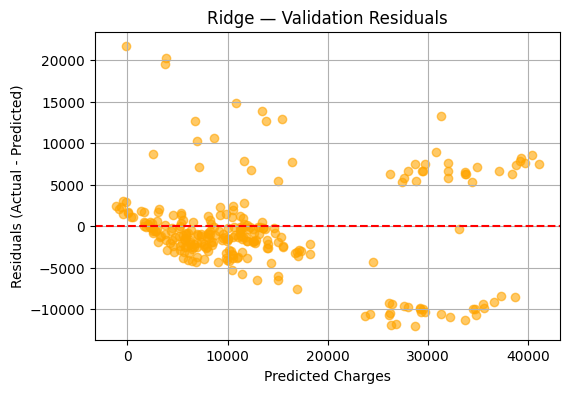

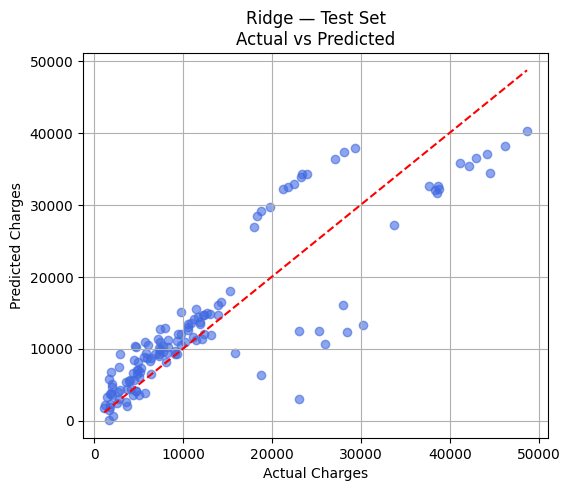

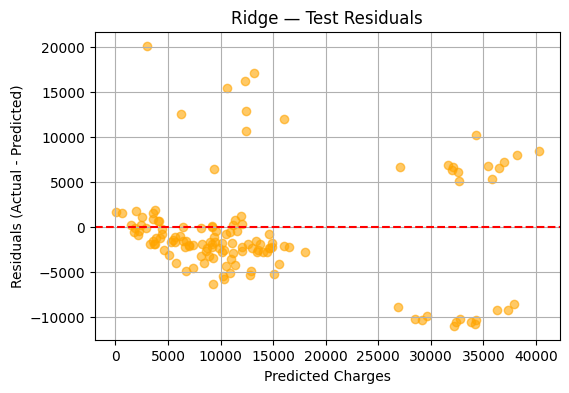

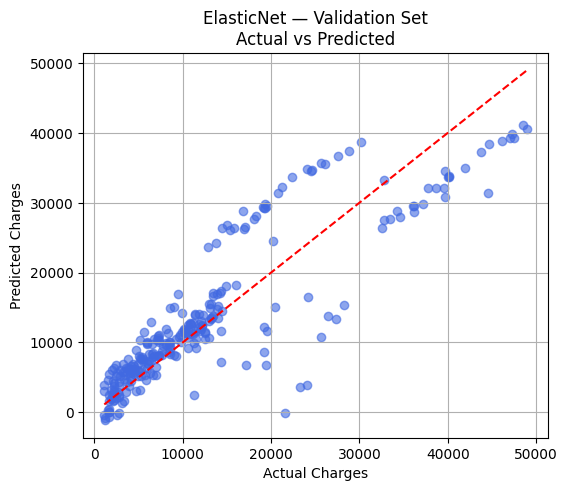

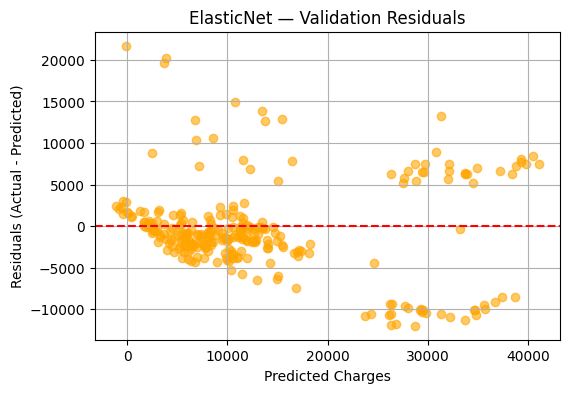

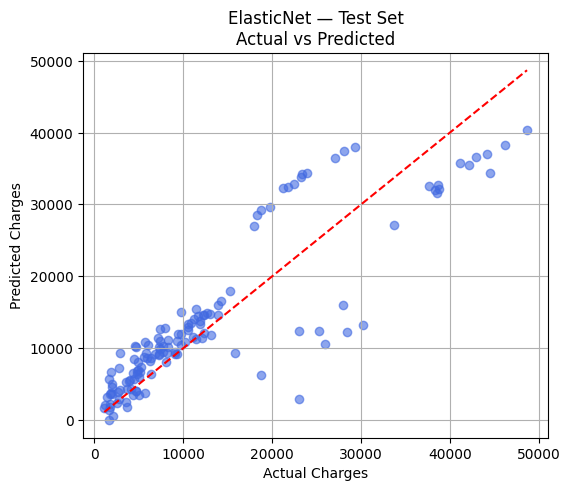

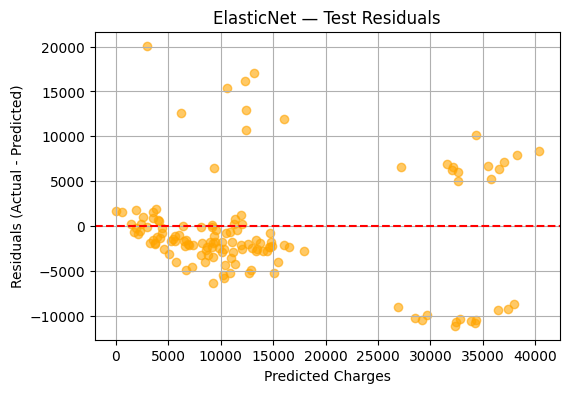

,Model,Dataset,MAE,RMSE,R2,Accuracy (%)
0,Linear,Validation,3797.765480,5464.167747,0.770779,77.077862
1,Linear,Test,4108.363541,5741.108691,0.761080,76.107964
2,Lasso,Validation,3794.051533,5460.761225,0.771064,77.106434
3,Lasso,Test,4109.429454,5742.420609,0.760970,76.097044
4,Ridge,Validation,3801.141409,5459.777855,0.771147,77.114678
5,Ridge,Test,4115.327374,5738.490860,0.761297,76.129748
6,ElasticNet,Validation,3794.051533,5460.761225,0.771064,77.106434
7,ElasticNet,Test,4109.429454,5742.420609,0.760970,76.097044


🏆 Best Model Based on Test RMSE:


,5
Model,Ridge
Dataset,Test
MAE,4115.327374
RMSE,5738.49086
R2,0.761297
Accuracy (%),76.129748



📌 Best Model for Feature Analysis: Ridge

🔥 Top Influential Features (sorted by |coefficient|):


,Feature,Coefficient
4,smoker_yes,9768.750574
0,age,3642.086034
1,bmi,1897.526954
2,children,453.138315
6,region_southeast,-432.121744
7,region_southwest,-407.290573
3,sex_male,-299.202214
5,region_northwest,-270.984145


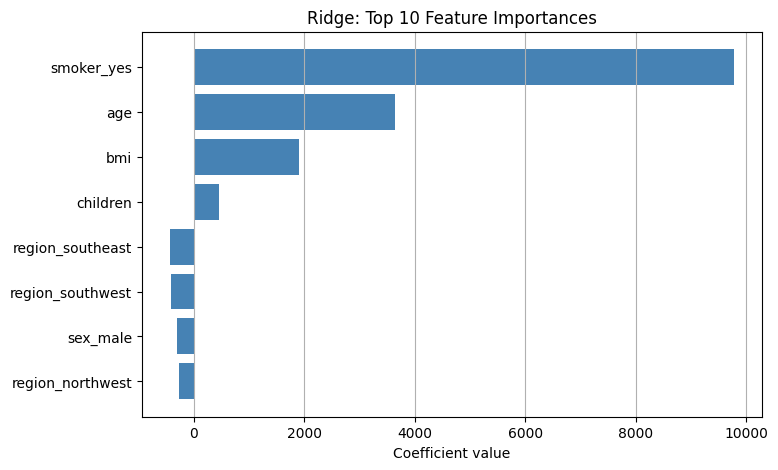


🧠 Why Some Features Matter More:

1️⃣ 'smoker_yes' → usually the strongest positive influence.
2️⃣ 'age' → higher age means higher health risk and cost.
3️⃣ 'bmi' → high BMI increases risk for lifestyle diseases.
4️⃣ 'children' → adds dependents → slightly higher charges.
5️⃣ 'region_*' & 'sex_male' → weaker, minor pricing differences.

📈 Larger |coeff| = stronger influence on predicted charges.
✅ Ridge & ElasticNet handle correlated predictors best.

🎯 Sample Test Prediction


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
1052,49,29.83,1,1,0,False,False,False


💰 Predicted Medical Charge (by Ridge): $11,107.03

🧩 Enter Your Own Details for Prediction:
Enter Age: 39
Enter BMI: 33.7
Enter number of children: 2
Sex (1 = Male, 0 = Female): 1
Smoker? (1 = Yes, 0 = No): 1
Enter region (northeast/northwest/southeast/southwest): southeast

💵 Predicted Medical Charge (using Ridge): $33,287.27


In [3]:
# ==============================================================
#  Machine Learning Regression Project: Medical Charges Prediction
#  Models: Linear, Lasso, Ridge, ElasticNet
#  Data Split: 70% Train, 20% Validation, 10% Test
#  Includes: K-Fold CV + Feature Importance + Visualization + Prediction
# ==============================================================

# STEP 1 — Upload the dataset
from google.colab import files
uploaded = files.upload()   # 👈 Choose your insurance.csv file

# STEP 2 — Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

# Step 3 - Load the dataset
df = pd.read_csv("insurance.csv")
print("✅ Dataset Loaded Successfully!")
display(df.head())

# STEP 4 — Preprocessing
df_processed = df.copy()
df_processed['sex_male'] = (df_processed['sex'] == 'male').astype(int)
df_processed['smoker_yes'] = (df_processed['smoker'] == 'yes').astype(int)
region_dummies = pd.get_dummies(df_processed['region'], prefix='region', drop_first=True)
df_processed = pd.concat([df_processed.drop(columns=['sex','smoker','region']), region_dummies], axis=1)

X = df_processed.drop(columns=['charges'])
y = df_processed['charges']

# STEP 5 — Data Split (70/20/10)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.10, random_state=42)
val_frac = 0.20 / 0.90
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_frac, random_state=42)
print(f"Shapes — Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# ==============================================================
# STEP 6 — Model Setup & K-Fold
# ==============================================================

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Linear': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LassoCV(cv=5, random_state=42, n_alphas=100, max_iter=5000))
    ]),
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5, scoring='neg_mean_squared_error'))
    ]),
    'ElasticNet': Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1.0],
                               cv=5, n_alphas=100, random_state=42, max_iter=5000))
    ])
}

# ==============================================================
# STEP 7 — Model Training, K-Fold CV & Evaluation
# ==============================================================

cv_results = []
for name, pipe in models.items():
    print(f"🔄 Running {name} with 5-Fold Cross Validation...")
    r2_scores = cross_val_score(pipe, X_train, y_train, cv=kfold, scoring='r2')
    neg_mse = cross_val_score(pipe, X_train, y_train, cv=kfold, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-neg_mse)

    cv_results.append({
        'Model': name,
        'R2_mean': np.mean(r2_scores),
        'R2_std': np.std(r2_scores),
        'RMSE_mean': np.mean(rmse_scores),
        'RMSE_std': np.std(rmse_scores)
    })

cv_df = pd.DataFrame(cv_results)
print("\n📊 Cross-Validation Summary:")
display(cv_df.sort_values(by='RMSE_mean'))

# ==============================================================
# STEP 8 — Validation & Test Performance + Plots
# ==============================================================

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

final_models = {}
metrics = []

for name, pipe in models.items():
    model = pipe.named_steps['model']
    model.fit(X_train_s, y_train)
    final_models[name] = model

    for subset, Xs, ys in [('Validation', X_val_s, y_val), ('Test', X_test_s, y_test)]:
        preds = model.predict(Xs)
        mae = mean_absolute_error(ys, preds)
        rmse = np.sqrt(mean_squared_error(ys, preds))
        r2 = r2_score(ys, preds)
        acc = max(0, min(1, r2)) * 100
        metrics.append([name, subset, mae, rmse, r2, acc])

        # 🔹 Plot Actual vs Predicted
        plt.figure(figsize=(6,5))
        plt.scatter(ys, preds, alpha=0.6, color='royalblue')
        plt.plot([ys.min(), ys.max()], [ys.min(), ys.max()], 'r--')
        plt.title(f"{name} — {subset} Set\nActual vs Predicted")
        plt.xlabel("Actual Charges")
        plt.ylabel("Predicted Charges")
        plt.grid(True)
        plt.show()

        # 🔹 Residual Plot
        residuals = ys - preds
        plt.figure(figsize=(6,4))
        plt.scatter(preds, residuals, alpha=0.6, color='orange')
        plt.axhline(0, color='red', linestyle='--')
        plt.title(f"{name} — {subset} Residuals")
        plt.xlabel("Predicted Charges")
        plt.ylabel("Residuals (Actual - Predicted)")
        plt.grid(True)
        plt.show()

metrics_df = pd.DataFrame(metrics, columns=['Model','Dataset','MAE','RMSE','R2','Accuracy (%)'])
display(metrics_df)

# ==============================================================
# STEP 9 — Compare Overall Model Performance
# ==============================================================

best_row = metrics_df.loc[metrics_df[metrics_df['Dataset']=='Test']['RMSE'].idxmin()]
print("🏆 Best Model Based on Test RMSE:")
display(best_row)

# ==============================================================
# STEP 10 — Feature Importance Analysis
# ==============================================================

best_model_name = best_row['Model']
best_model = final_models[best_model_name]
print(f"\n📌 Best Model for Feature Analysis: {best_model_name}")

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\n🔥 Top Influential Features (sorted by |coefficient|):")
display(coef_df.head(10))

plt.figure(figsize=(8,5))
plt.barh(coef_df['Feature'].head(10), coef_df['Coefficient'].head(10), color='steelblue')
plt.title(f"{best_model_name}: Top 10 Feature Importances")
plt.xlabel("Coefficient value")
plt.gca().invert_yaxis()
plt.grid(True, axis='x')
plt.show()



# ==============================================================
# STEP 11 — Explanation of Feature Importance
# ==============================================================

print("""
🧠 Why Some Features Matter More:

1️⃣ 'smoker_yes' → usually the strongest positive influence.
2️⃣ 'age' → higher age means higher health risk and cost.
3️⃣ 'bmi' → high BMI increases risk for lifestyle diseases.
4️⃣ 'children' → adds dependents → slightly higher charges.
5️⃣ 'region_*' & 'sex_male' → weaker, minor pricing differences.

📈 Larger |coeff| = stronger influence on predicted charges.
✅ Ridge & ElasticNet handle correlated predictors best.
""")

# ==============================================================
# STEP 12 — Predicting on a Test Sample
# ==============================================================

# Pick one random test record
sample = X_test.sample(1, random_state=42)
sample_scaled = scaler.transform(sample)
predicted_charge = best_model.predict(sample_scaled)[0]

print("🎯 Sample Test Prediction")
display(sample)
print(f"💰 Predicted Medical Charge (by {best_model_name}): ${predicted_charge:,.2f}")

# ==============================================================
# STEP 13 — User Input Prediction
# ==============================================================

print("\n🧩 Enter Your Own Details for Prediction:")

# Ask user for input (you can adjust input prompts as needed)
user_data = {
    'age': float(input("Enter Age: ")),
    'bmi': float(input("Enter BMI: ")),
    'children': int(input("Enter number of children: ")),
    'sex_male': int(input("Sex (1 = Male, 0 = Female): ")),
    'smoker_yes': int(input("Smoker? (1 = Yes, 0 = No): ")),
    'region_northwest': 0,
    'region_southeast': 0,
    'region_southwest': 0
}

# Select region
region = input("Enter region (northeast/northwest/southeast/southwest): ").strip().lower()
if region in ['northwest', 'southeast', 'southwest']:
    user_data[f'region_{region}'] = 1

# Convert to DataFrame
user_df = pd.DataFrame([user_data])
user_scaled = scaler.transform(user_df)

# Predict
predicted_user_charge = best_model.predict(user_scaled)[0]
print(f"\n💵 Predicted Medical Charge (using {best_model_name}): ${predicted_user_charge:,.2f}")
